In [703]:
#Figure 2:
#Compare chromotripsis vs non-chromotripsis between grades

In [675]:
  library(ComplexHeatmap)
  library(circlize)
  library(dplyr)
  library(stringr)
library(dplyr)
library(psych)
library(pheatmap)
library(RColorBrewer)
library(dplyr)
library(psych)
library(pheatmap)
library(RColorBrewer)
library(viridis)
library(tidyverse)
library(psych)
library(pheatmap)
library(RColorBrewer)
library(dplyr)
library(tidyr)



In [676]:

BND_anno <- read.delim2(
  #"/home/mjehangir/sv_annotation.txt",
      "/home/mjehangir/complex_event.txt",
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)

In [677]:
colnames(BND_anno)

[1] "Samples"                                                  
[2] "Templated.Insertion.Chains..TICs..like.complex.insertions"
[3] "chromothripsis"                                           
[4] "foldback.translocation"                                   
[5] "complex.rearranegment.single.chr"                         
[6] "complex.rearranegment.multiple.chr"                       
[7] "chromoplexy"                                              
[8] "X"

In [678]:
# clinical data for grade 
clinic <- read.table(
  #"/home/mjehangir/sv_annotation.txt",
      "/home/mjehangir/telomere-sv-analysis/data/clinical_data_merged.txt",

  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)

#Read data 
ecDNA <- read.csv("/home/mjehangir/telomere-sv-analysis/data/ecDNA_arm_level.csv")
HAR <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/HARs_with_chr-arms.txt")
TEL <- read.csv("/home/mjehangir/telomere-sv-analysis/data/gliomas_telomers.csv")
ploidy <- read.delim2("/tgen_labs/barthel/projects/Jenkins_Mayo/aneuploidy/Glioma_v2_output_taylor_aneuploidy_summary.txt")
SV_CNV  <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/mixed_model_SVs_CNV_TL_with_SV_final.tsv")

In [679]:
head(BND_anno)
head(clinic)
head(ecDNA)
head(HAR)
head(SV_CNV)
head(TEL)
head(ploidy)
head(SV_CNV)

,Samples,Templated.Insertion.Chains..TICs..like.complex.insertions,chromothripsis,foldback.translocation,complex.rearranegment.single.chr,complex.rearranegment.multiple.chr,chromoplexy,X
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,3188,chr6,"(chr5,chr14)","(chr20,chr11)",chr13,,,NA
2,3988,"(chr2,chr5)",,,"chr1,chr2,chr3",,,NA
3,6265D,,chr5,chr1,"chr18,chr3,chr13","(chr12,chr17)",,NA
4,6266D,,,,chr10,"chr3,chr9",,NA
5,6277A,"(chr1, chr2)(chr9,chr8.chr7)(chr9,chr16),chr12,(chr20,chr8)","chr13,chr2","(chr18,chr14)(chr18,chr4)",chr8,"(chr6,chr10.chr19),(chr10,chr13,chr18)(chr2,chr10,chr6)(chr7,chr8,chr9)(chr12,chr13.chr5)","chr18,chr3,chr7,chr8,chr9",NA
6,6314E,"(chr11.chr22)(chr19,chr14)",,,,,,NA


,ID,Age,Grade,CDKN2A.B,TP53,ATRX,onco_Alterations,ONT_Alterations,surgical,dead,days
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>
1,2436A,NA,3,NA,NA,NA,5,40,,1,4629
2,3188,NA,3,NA,NA,NA,16,107,,1,1349
3,3988,0,2,2,0,0,17,105,,1,1536
4,6265D,33,3,1,0,0,42,87,,1,950
5,6266D,40,2,1,0,0,28,105,,1,1195
6,6269C,23,3,2,0,0,14,214,,0,2300


,sample,chr_arm,total_prop,n_fragments,avg_TL_kb,avg_norm_TL,circ_list,Burden_Group
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>
1,2436A,chr14q,72,1,3.490600,-1.5358237,25,Low/Med Burden
2,2436A,chr17q,165,5,4.601500,-0.5944495,33,Low/Med Burden
3,2436A,chr1q,216,2,5.051167,-0.2134030,1,High Burden
4,2436A,chr6q,58,1,5.896929,0.5032938,18,Low/Med Burden
5,2436A,chr7q,174,3,6.483083,1.0000000,18,Low/Med Burden
6,3188,chr11p,115,1,2.651250,-0.4327284,16,Low/Med Burden


,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag,chr_arm
,<chr>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
1,2436A,1,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0,chr1p
2,2436A,1,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1,chr1q
3,2436A,10,88303635,101719380,68,0.0066,13415745,Neutral,0.0116,0.05922987,0,chr10q
4,2436A,10,101919615,104722905,15,-0.104,2803290,Neutral,0.0116,0.05922987,0,chr10q
5,2436A,10,104923140,112932540,41,-0.0198,8009400,Neutral,0.0116,0.05922987,0,chr10q
6,2436A,10,113132775,120741705,39,-0.4022,7608930,Loss,0.0116,0.05922987,0,chr10q


,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,sv_rate_BND,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_BND,sv_proportion_INS,sv_proportion_INV
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,2436A,chr1p,5.221,-0.0694866181766826,NA,NA,NA,NA,0,0.0161227564751066,0.00806137823755329,0.0322455129502132,0,0,2.5825431321825e-4,0,0,0
2,2436A,chr1q,5.05116666666667,-0.213403008262126,0.00804252494716845,0,0.00160972745322566,0,0.00804252494716845,0,0.0160850498943369,0,0,2.1262827455324e-4,0,0,0,0
3,3188,chr1p,1.6425,-2.95775969962453,0,0.0161227564751066,0,0.367876400885149,0.0322455129502132,0,0.386946155402558,0.00806137823755329,0,8.0251020354843e-5,0,0,0,0
4,3188,chr1q,3.0865,0.656758448060075,0.00804252494716845,0,0.00804856488340377,0,0.00804252494716845,0,0.31365847293957,0,0,4.44751629578415e-6,0,0,0,0
5,3988,chr1p,2.3475,-2.53325753268903,NA,NA,NA,NA,0,0,0.330516507739685,0.0161227564751066,0,0,0,0,0,0
6,3988,chr1q,5.083,-0.459730907712716,NA,NA,NA,NA,0,0,0.490594021777276,0,0,0,0,0.543766765296707,0,0


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm
,<chr>,<chr>,<dbl>,<int>,<chr>
1,2436A,chr1p,5221.000,1,p
2,2436A,chr1q,5051.167,1,q
3,3188,chr1p,1642.500,1,p
4,3188,chr1q,3086.500,1,q
5,3988,chr1p,2347.500,1,p
6,3988,chr1q,5083.000,1,q


,SampleID,prop_aneuploidy,aneuploidy_score,aneuploidy_amp_score,aneuploidy_del_score,max_loss_arm_n,max_loss_arm_wmean,max_loss_arm_wsd,max_gain_arm_n,max_gain_arm_wmean,max_gain_arm_wsd
,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>
1,2436A,0.0375,0,0,0,2,0.691185015278888,518.771802990858,2,1.09095719505308,121.661546230536
2,3188,0.592,10,5,5,7,0.590461955048306,49.1845308746792,8,1.44908158255162,186.335203048141
3,3988,0.1956,3,2,1,6,0.743225694379821,145.352601019215,3,1.46445047948054,131.754807440957
4,6265D,0.3671,1,0,1,5,0.545118863327445,492.269573586538,2,1.0794143851207,182.955071023484
5,6266D,0.1704,1,1,0,2,0.950697617969137,138.285110997849,8,1.30197238863614,138.827934723301
6,6269C,0.358,2,1,1,2,0.741821034450564,332.957653014079,2,1.31452265725842,313.209043063345


,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,sv_rate_BND,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_BND,sv_proportion_INS,sv_proportion_INV
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,2436A,chr1p,5.221,-0.0694866181766826,NA,NA,NA,NA,0,0.0161227564751066,0.00806137823755329,0.0322455129502132,0,0,2.5825431321825e-4,0,0,0
2,2436A,chr1q,5.05116666666667,-0.213403008262126,0.00804252494716845,0,0.00160972745322566,0,0.00804252494716845,0,0.0160850498943369,0,0,2.1262827455324e-4,0,0,0,0
3,3188,chr1p,1.6425,-2.95775969962453,0,0.0161227564751066,0,0.367876400885149,0.0322455129502132,0,0.386946155402558,0.00806137823755329,0,8.0251020354843e-5,0,0,0,0
4,3188,chr1q,3.0865,0.656758448060075,0.00804252494716845,0,0.00804856488340377,0,0.00804252494716845,0,0.31365847293957,0,0,4.44751629578415e-6,0,0,0,0
5,3988,chr1p,2.3475,-2.53325753268903,NA,NA,NA,NA,0,0,0.330516507739685,0.0161227564751066,0,0,0,0,0,0
6,3988,chr1q,5.083,-0.459730907712716,NA,NA,NA,NA,0,0,0.490594021777276,0,0,0,0,0.543766765296707,0,0


In [653]:
library(dplyr)

# 1. Complex SVs (BND_anno) - Ensure 1 row per sample
bnd_sample <- BND_anno %>%
  group_by(Samples) %>%
  summarise(
    # We count the number of "(" to identify the number of distinct grouped events
    # If there are NO parentheses but a chromosome is listed (e.g., "chr13"), 
    # we treat that as 1 event as well.
    across(
      c(Templated.Insertion.Chains..TICs..like.complex.insertions, 
        chromothripsis, 
        foldback.translocation, 
        complex.rearranegment.single.chr, 
        complex.rearranegment.multiple.chr, 
        chromoplexy),
      ~ sum(ifelse(str_detect(., "\\("), 
                   str_count(., "\\("), 
                   ifelse(. != "" & !is.na(.), 1, 0)), na.rm = TRUE)
    )
  ) %>%
  select(
    Sample = Samples,
    TIC_Events = Templated.Insertion.Chains..TICs..like.complex.insertions,
    Chromothripsis = chromothripsis,
    Foldbacks = foldback.translocation,
    Single_Chr_SV = complex.rearranegment.single.chr,
    Multi_Chr_SV = complex.rearranegment.multiple.chr,
    Chromoplexy = chromoplexy)

# 2. ecDNA (Summing arm-level proportions and fragments)
ecdna_sample <- ecDNA %>%
  group_by(sample) %>%
  summarise(
   # ecDNA = paste(unique(circ_list), collapse = "; "),
    ecdna_proportion = sum(total_prop, na.rm = TRUE),
    ecdna_burden = sum(n_fragments, na.rm = TRUE)
  ) %>%
  rename(Sample = sample)

# 3. HARs (Summing the ecDNA_flag to count total HAR events per sample)
har_sample <- HAR %>%
  # Ensure the flag is treated as a number
  mutate(ecDNA_flag = as.numeric(as.character(ecDNA_flag))) %>%
  group_by(ID) %>%
  summarise(HARs_Presence_Count = sum(ecDNA_flag, na.rm = TRUE)) %>%
  rename(Sample = ID)

# 4. Telomeres (Average TL per sample)
tel_sample <- TEL %>%
  group_by(Sample_prefix) %>%
  summarise(Avg_TL = mean(final_average_TL_p75, na.rm = TRUE)) %>%
  rename(Sample = Sample_prefix)

# 5. Clinical (Grade)
clinic_clean <- clinic %>% 
  select(Sample = ID, Grade) %>%
  distinct() 
# 6. Ploidy & Aneuploidy
ploidy_sample <- ploidy %>%
  select(Sample = SampleID, aneuploidy_score, aneuploidy_amp_score, aneuploidy_del_score) %>%
  mutate(across(starts_with("aneu"), as.numeric)) %>%
  group_by(Sample) %>%
  summarise(across(everything(), mean, na.rm = TRUE))

# 7. SV & CNV (Summing all rates/proportions across arms)
sv_cnv_sample <- SV_CNV %>%
  mutate(across(starts_with("cnv_") | starts_with("sv_"), as.numeric)) %>%
  group_by(Sample_ID) %>%
  summarise(
    Total_CNV_Gain_Rate = sum(cnv_rate_per_mb_Gain, na.rm = TRUE),
    Total_CNV_Loss_Rate = sum(cnv_rate_per_mb_Loss, na.rm = TRUE),
    Total_CNV_Gain_Prop = sum(cnv_proportion_per_mb_Gain, na.rm = TRUE),
    Total_CNV_Loss_Prop = sum(cnv_proportion_per_mb_Loss, na.rm = TRUE),
    Total_SV_DEL_Rate  = sum(sv_rate_DEL, na.rm = TRUE),
    Total_SV_DUP_Rate  = sum(sv_rate_DUP, na.rm = TRUE),
    Total_SV_BND_Rate  = sum(sv_rate_BND, na.rm = TRUE),
    Total_SV_INS_Rate  = sum(sv_rate_INS, na.rm = TRUE),
    Total_SV_INV_Rate  = sum(sv_rate_INV, na.rm = TRUE),
    Total_SV_DEL_Prop  = sum(sv_proportion_DEL, na.rm = TRUE),
    Total_SV_DUP_Prop  = sum(sv_proportion_DUP, na.rm = TRUE),
    Total_SV_BND_Prop  = sum(sv_proportion_BND, na.rm = TRUE),
    Total_SV_INS_Prop  = sum(sv_proportion_INS, na.rm = TRUE),
    Total_SV_INV_Prop  = sum(sv_proportion_INV, na.rm = TRUE)
  ) %>%
  rename(Sample = Sample_ID)

# --- THE FINAL MERGE ---
# Using full_join to ensure no samples are lost, then replacing NAs with 0 where appropriate
final_df <- bnd_sample %>%
  full_join(ecdna_sample, by = "Sample") %>%
  full_join(har_sample, by = "Sample") %>%
  full_join(clinic_clean, by = "Sample") %>%
  full_join(tel_sample, by = "Sample") %>%
  full_join(ploidy_sample, by = "Sample") %>%
  full_join(sv_cnv_sample, by = "Sample")

# Optional: Replace NA in numeric columns with 0
final_df <- final_df %>%
  mutate(across(where(is.numeric), ~replace_na(., 0)))

head(final_df)

Sample,TIC_Events,Chromothripsis,Foldbacks,Single_Chr_SV,Multi_Chr_SV,Chromoplexy,ecdna_proportion,ecdna_burden,HARs_Presence_Count,⋯,Total_SV_DEL_Rate,Total_SV_DUP_Rate,Total_SV_BND_Rate,Total_SV_INS_Rate,Total_SV_INV_Rate,Total_SV_DEL_Prop,Total_SV_DUP_Prop,Total_SV_BND_Prop,Total_SV_INS_Prop,Total_SV_INV_Prop
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3188,1,1,1,1,0,0,371,8,0,⋯,0.7618921,0.26761922,14.839776,0.21858847,0.00000000,1.8928577722,4.6290017442,68.377226,0,0.000000000
3988,1,0,0,1,0,0,117,3,8,⋯,0.2561799,0.15864747,11.688126,0.26829818,0.00000000,0.0640126294,0.9139873163,5.709113,0,0.000000000
6265D,0,1,1,1,1,0,1935,18,3,⋯,0.4728796,0.24823703,3.912967,0.27440298,0.01062598,0.4432185169,0.0435687351,5.018407,0,0.001061217
6266D,0,0,0,1,1,0,69,3,9,⋯,0.7925440,0.09663768,1.529044,0.51214722,0.00000000,0.0242787121,0.0098290410,2.916837,0,0.000000000
6277A,4,1,2,1,5,1,105,7,0,⋯,0.6806104,0.22253385,2.665145,0.38865877,0.03615245,2.4121522535,1.8636589238,15.756663,0,0.092091761
6314E,2,0,0,0,0,0,16,2,0,⋯,0.3080355,0.05968056,6.404926,0.09327418,0.00000000,0.0005451175,0.0006320504,1.250802,0,0.000000000


In [654]:
nrow(bnd_sample)

[1] 15

In [655]:
library(dplyr)
library(stringr)
library(tidyr)

# 1. Complex SVs: Count "(" as events, or 1 if just a chromosome name, 0 if empty
bnd_sample <- BND_anno %>%
  group_by(Samples) %>%
  summarise(
    across(
      c(Templated.Insertion.Chains..TICs..like.complex.insertions, 
        chromothripsis, 
        foldback.translocation, 
        complex.rearranegment.single.chr, 
        complex.rearranegment.multiple.chr, 
        chromoplexy),
      ~ sum(ifelse(str_detect(., "\\("), 
                   str_count(., "\\("), 
                   ifelse(. != "" & !is.na(.) & . != "NA", 1, 0)), na.rm = TRUE)
    )
  ) %>%
  rename(Sample = Samples,
         TIC_Events = Templated.Insertion.Chains..TICs..like.complex.insertions,
         Chromothripsis = chromothripsis,
         Foldbacks = foldback.translocation,
         Single_Chr_SV = complex.rearranegment.single.chr,
         Multi_Chr_SV = complex.rearranegment.multiple.chr,
         Chromoplexy = chromoplexy)

# 2. ecDNA: Summing proportions and fragments
ecdna_sample <- ecDNA %>%
  group_by(sample) %>%
  summarise(
    ecDNA_Count = n_distinct(circ_list, na.rm = TRUE),
    ecdna_proportion = sum(as.numeric(total_prop), na.rm = TRUE),
    ecdna_burden = sum(as.numeric(n_fragments), na.rm = TRUE)
  ) %>%
  rename(Sample = sample)

# 3. HARs: Summing ecDNA_flag (1=presence, 0=absence)
har_sample <- HAR %>%
  mutate(ecDNA_flag = as.numeric(as.character(ecDNA_flag))) %>%
  group_by(ID) %>%
  summarise(HARs_Presence_Count = sum(ecDNA_flag, na.rm = TRUE)) %>%
  rename(Sample = ID)

# 4. Telomeres: Genome-wide Average
tel_sample <- TEL %>%
  group_by(Sample_prefix) %>%
  summarise(Avg_TL = median(as.numeric(final_average_TL_p75), na.rm = TRUE)) %>%
  rename(Sample = Sample_prefix)

# 5. Ploidy/Aneuploidy: Average scores
ploidy_sample <- ploidy %>%
  mutate(across(starts_with("aneu"), as.numeric)) %>%
  group_by(SampleID) %>%
  summarise(across(starts_with("aneu"), mean, na.rm = TRUE)) %>%
  rename(Sample = SampleID)

# 6. SV & CNV: Summing all arm-level rates and proportions
sv_cnv_sample <- SV_CNV %>%
  mutate(across(starts_with(c("cnv_", "sv_")), as.numeric)) %>%
  group_by(Sample_ID) %>%
  summarise(across(starts_with(c("cnv_", "sv_")), sum, na.rm = TRUE)) %>%
  rename(Sample = Sample_ID)

# 7. Clinical Data (Grade)
clinic_clean <- clinic %>% 
  select(Sample = ID, Grade) %>% 
  distinct()

# --- THE FINAL UNIVERSAL MERGE ---
# Using full_join ensures NO sample is lost from any file
final_df <- clinic_clean %>%
  full_join(bnd_sample, by = "Sample") %>%
  full_join(ecdna_sample, by = "Sample") %>%
  full_join(har_sample, by = "Sample") %>%
  full_join(tel_sample, by = "Sample") %>%
  full_join(ploidy_sample, by = "Sample") %>%
  full_join(sv_cnv_sample, by = "Sample")

# --- FILL MISSING VALUES WITH 0 ---
# This converts every NA in the entire data frame to 0
final_df[is.na(final_df)] <- 0

# Check final dimensions
print(paste("Final sample count:", nrow(final_df)))
head(final_df)

[1] "Final sample count: 20"


,Sample,Grade,TIC_Events,Chromothripsis,Foldbacks,Single_Chr_SV,Multi_Chr_SV,Chromoplexy,ecDNA_Count,ecdna_proportion,⋯,sv_rate_DEL,sv_rate_DUP,sv_rate_BND,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_BND,sv_proportion_INS,sv_proportion_INV
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,3,0,0,0,0,0,0,4,685,⋯,0.4955663,0.15444896,0.996001,0.3567866,0.00000000,0.1630464286,0.0008138958,1.6070479,0,0.000000000
2,3188,3,1,1,1,1,0,0,5,371,⋯,0.7618921,0.26761922,14.839776,0.2185885,0.00000000,1.8928577722,4.6290017442,68.3772262,0,0.000000000
3,3988,2,1,0,0,1,0,0,1,117,⋯,0.2561799,0.15864747,11.688126,0.2682982,0.00000000,0.0640126294,0.9139873163,5.7091135,0,0.000000000
4,6265D,3,0,1,1,1,1,0,8,1935,⋯,0.4728796,0.24823703,3.912967,0.2744030,0.01062598,0.4432185169,0.0435687351,5.0184070,0,0.001061217
5,6266D,2,0,0,0,1,1,0,2,69,⋯,0.7925440,0.09663768,1.529044,0.5121472,0.00000000,0.0242787121,0.0098290410,2.9168374,0,0.000000000
6,6269C,3,0,0,0,0,0,0,2,114,⋯,0.1558395,0.06599280,4.702000,0.2278273,0.00000000,0.0006358799,0.0001991544,0.3061699,0,0.000000000


In [656]:
nrow(final_df)

[1] 20

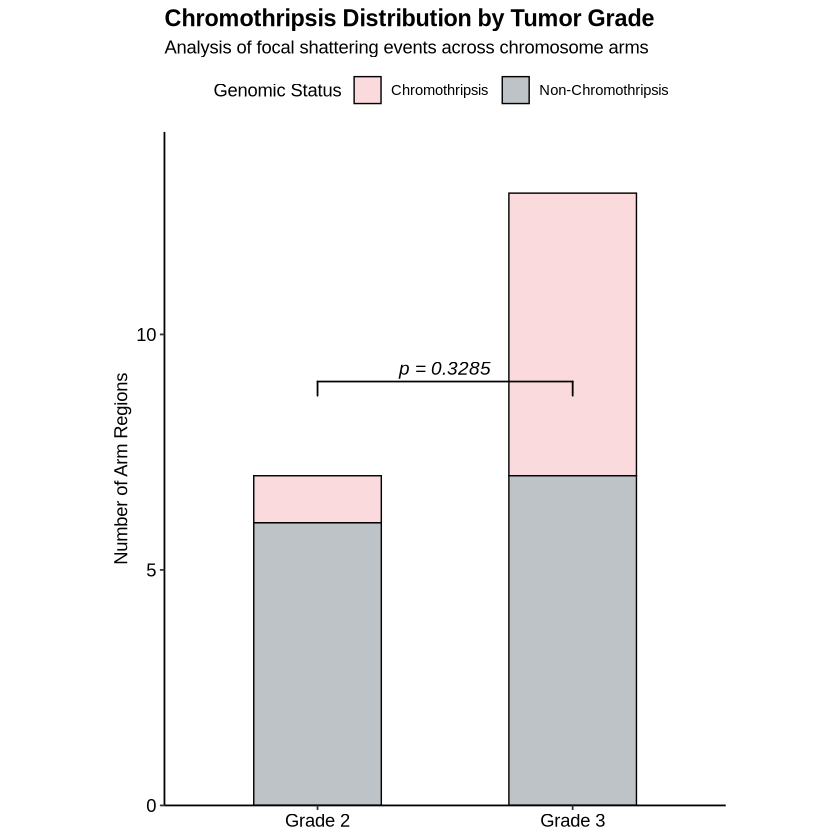

In [665]:


# 1. Prepare the data: Identify if an arm is Chromothripsis-positive
grade_summary <- final_df %>%
  mutate(Status = if_else(Chromothripsis > 0, "Chromothripsis", "Non-Chromothripsis")) %>%
  group_by(Grade, Status) %>%
  summarise(Count = n(), .groups = "drop") %>%
  # Ensure Grade is a factor for clean plotting
  mutate(Grade = paste("Grade", Grade))

# 2. Run Fisher's Exact Test for the annotation
# We create a contingency table from the summary
contingency_tab <- grade_summary %>%
  pivot_wider(names_from = Status, values_from = Count, values_fill = 0) %>%
  select(Chromothripsis, `Non-Chromothripsis`) %>%
  as.matrix()

p_val <- fisher.test(contingency_tab)$p.value

# 3. Generate the Upgraded Plot
ggplot(grade_summary, aes(x = Grade, y = Count, fill = Status)) +
  geom_col(color = "black", width = 0.5, size = 0.4) +
  scale_fill_manual(values = c("Chromothripsis" = "#FADADD", "Non-Chromothripsis" = "#BDC3C7")) +
  
  # Add Significance Annotation
  geom_signif(
    y_position = max(grade_summary$Count) + 2, 
    xmin = 1, xmax = 2,
    annotation = paste0("p = ", round(p_val, 4)),
    tip_length = 0.05, textsize = 4, fontface = "italic"
  ) +
  
  # Styling for Nature-style aesthetics
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  theme_classic() +
  labs(
    title = "Chromothripsis Distribution by Tumor Grade",
    subtitle = "Analysis of focal shattering events across chromosome arms",
    x = NULL,
    y = "Number of Arm Regions",
    fill = "Genomic Status"
  ) +
  theme(
    legend.position = "top",
    plot.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 11, color = "black"),
    aspect.ratio = 1.2
  )

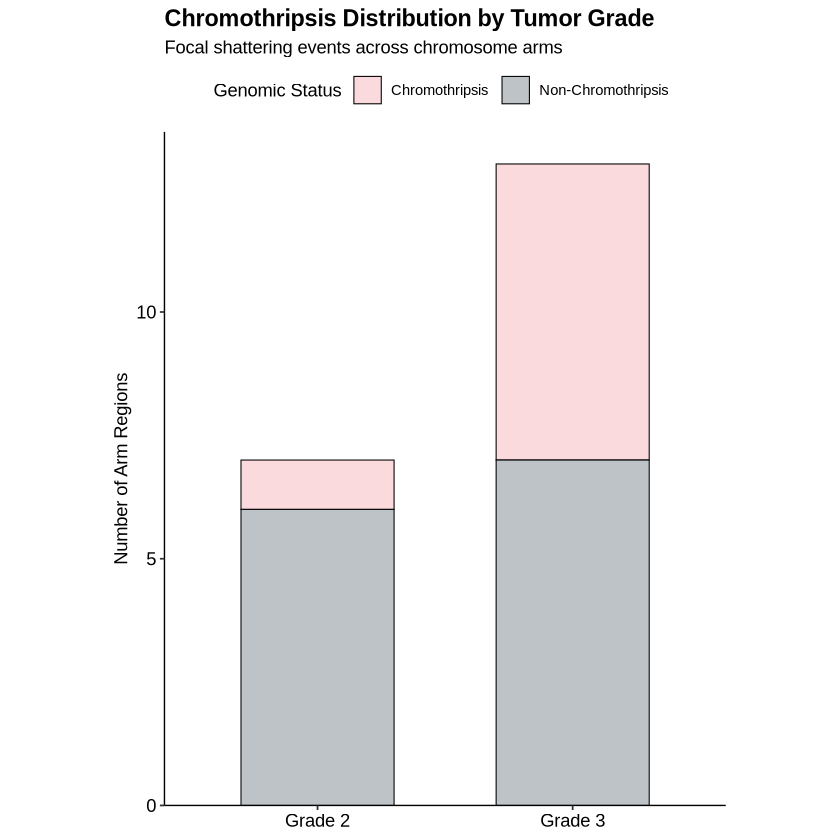

In [674]:
library(ggplot2)
library(dplyr)

# 1. Prepare the data
grade_summary <- final_df %>%
  mutate(Status = if_else(Chromothripsis > 0, "Chromothripsis", "Non-Chromothripsis")) %>%
  group_by(Grade, Status) %>%
  summarise(Count = n(), .groups = "drop") %>%
  mutate(Grade = paste("Grade", Grade))

# 2. Generate the Clean Plot (No Stats)
ggplot(grade_summary, aes(x = Grade, y = Count, fill = Status)) +
  # Bar layer with thin black borders for a "Nature" look
  geom_col(color = "black", width = 0.6, size = 0.3) +
  
  # Professional color palette (Muted/Medical tones)
  scale_fill_manual(values = c("Chromothripsis" = "#FADADD", "Non-Chromothripsis" = "#BDC3C7")) +
  
  # Axis and Title labels
  labs(
    title = "Chromothripsis Distribution by Tumor Grade",
    subtitle = "Focal shattering events across chromosome arms",
    x = NULL,
    y = "Number of Arm Regions",
    fill = "Genomic Status"
  ) +
  
  # Minimalist styling
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) + # Smaller top margin
  theme_classic() +
  theme(
    legend.position = "top",
    plot.title = element_text(face = "bold", size = 14),
    axis.text = element_text(size = 11, color = "black"),
    axis.line = element_line(size = 0.4),
    aspect.ratio = 1.2
  )

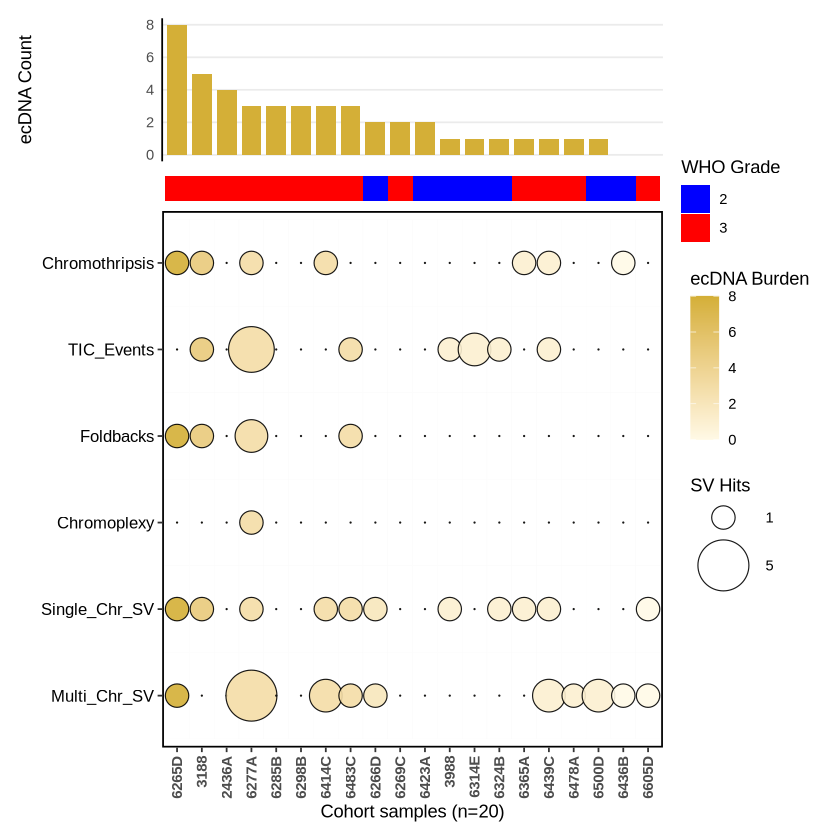

In [673]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)

# --- 1. DATA PREP (Ensuring all 20 samples are locked) ---
df_sample_level <- final_df %>%
  group_by(Sample) %>%
  summarise(
    ecDNA_Count      = sum(ecDNA_Count, na.rm = TRUE),
    Grade            = first(Grade),
    Chromothripsis   = sum(Chromothripsis, na.rm = TRUE),
    TIC_Events       = sum(TIC_Events, na.rm = TRUE),
    Foldbacks        = sum(Foldbacks, na.rm = TRUE),
    Chromoplexy      = sum(Chromoplexy, na.rm = TRUE),
    Single_Chr_SV    = sum(Single_Chr_SV, na.rm = TRUE),
    Multi_Chr_SV     = sum(Multi_Chr_SV, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(Grade = ifelse(is.na(Grade), "Unknown", as.character(Grade))) %>%
  arrange(desc(ecDNA_Count))

sample_order <- df_sample_level$Sample

df_bubbles_long <- df_sample_level %>%
  pivot_longer(
    cols = c(Chromothripsis, TIC_Events, Foldbacks, 
             Chromoplexy, Single_Chr_SV, Multi_Chr_SV),
    names_to = "SV_Type",
    values_to = "Event_Count"
  ) %>%
  mutate(
    Sample = factor(Sample, levels = sample_order),
    SV_Type = factor(SV_Type, levels = rev(c("Chromothripsis", "TIC_Events", "Foldbacks", 
                                            "Chromoplexy", "Single_Chr_SV", "Multi_Chr_SV")))
  )

# --- 2. PLOT A: GOLDEN TOP BAR ---
p_top <- ggplot(df_sample_level, aes(x = factor(Sample, levels = sample_order), y = ecDNA_Count)) +
  geom_col(fill = "#D4AF37", width = 0.8) + # Metallic Gold
  theme_minimal() +
  theme(
    axis.text.x = element_blank(), 
    axis.title.x = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line.y = element_line(size = 0.5)
  ) +
  labs(y = "ecDNA Count")

# --- 3. PLOT B: GRADE BAR ---
p_grade <- ggplot(df_sample_level, aes(x = factor(Sample, levels = sample_order), y = 1, fill = Grade)) +
  geom_tile() +
  scale_fill_manual(values = c("2" = "blue", "3" = "red", "Unknown" = "grey80"), 
                    name = "WHO Grade") +
  theme_void() +
  theme(legend.position = "right")

# --- 4. PLOT C: GOLDEN BUBBLE MATRIX ---
p_bottom <- ggplot(df_bubbles_long, aes(x = Sample, y = SV_Type)) +
  geom_tile(fill = "white", color = "grey98") +
  geom_point(aes(size = Event_Count, fill = ecDNA_Count), 
             color = "black", shape = 21, stroke = 0.5, alpha = 0.9) +
  scale_size_area(max_size = 14, name = "SV Hits", limits = c(0, NA), breaks = c(1, 5, 10, 20)) +
  # Continuous Golden Gradient
  scale_fill_gradient(low = "#FFF9E6", high = "#D4AF37", name = "ecDNA burden") + 
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, face = "bold", size = 9),
    axis.text.y = element_text(size = 10, color = "black"),
    panel.grid.major = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1)
  ) +
  labs(x = "Cohort samples (n=20)", y = NULL)

# --- 5. COMBINE ---
final_plot <- (p_top / p_grade / p_bottom) + 
  plot_layout(heights = c(0.8, 0.15, 3), guides = 'collect') & 
  theme(legend.box = "vertical")

print(final_plot)

In [657]:
colnames(final_df)

[1] "Sample"                     "Grade"                     
 [3] "TIC_Events"                 "Chromothripsis"            
 [5] "Foldbacks"                  "Single_Chr_SV"             
 [7] "Multi_Chr_SV"               "Chromoplexy"               
 [9] "ecDNA_Count"                "ecdna_proportion"          
[11] "ecdna_burden"               "HARs_Presence_Count"       
[13] "Avg_TL"                     "aneuploidy_score"          
[15] "aneuploidy_amp_score"       "aneuploidy_del_score"      
[17] "cnv_rate_per_mb_Gain"       "cnv_rate_per_mb_Loss"      
[19] "cnv_proportion_per_mb_Gain" "cnv_proportion_per_mb_Loss"
[21] "sv_rate_DEL"                "sv_rate_DUP"               
[23] "sv_rate_BND"                "sv_rate_INS"               
[25] "sv_rate_INV"                "sv_proportion_DEL"         
[27] "sv_proportion_DUP"          "sv_proportion_BND"         
[29] "sv_proportion_INS"          "sv_proportion_INV"

In [658]:
# This creates a clean, comma-separated file for your records
write.csv(final_master_df, 
          file = "/home/mjehangir/telomere-sv-analysis/data/BND_subtype_final_master_data.csv", 
          row.names = FALSE)

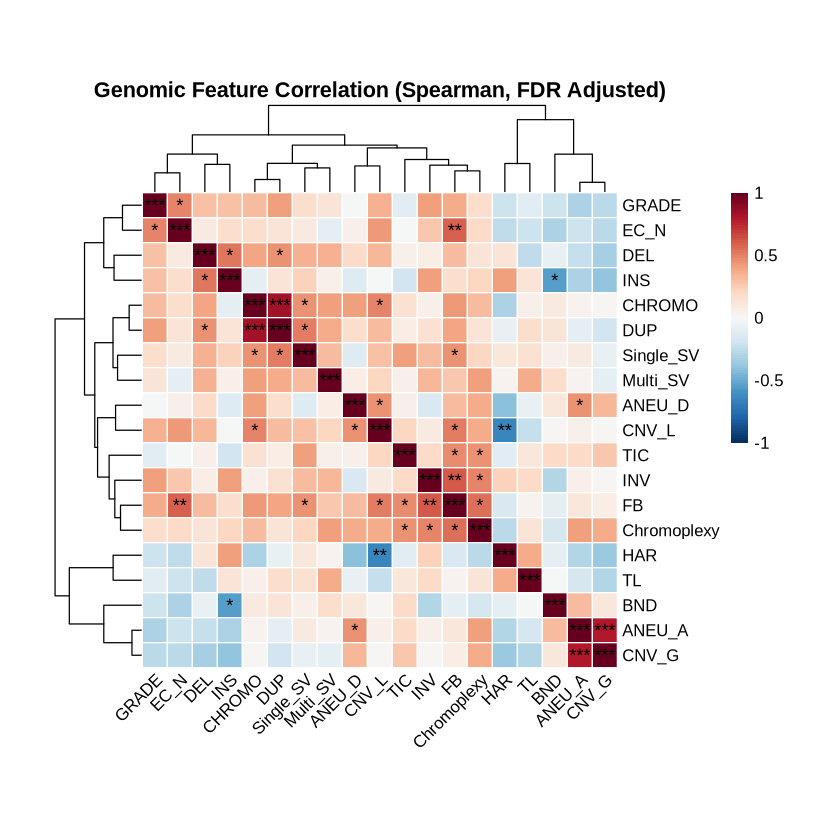

In [664]:

# --- 1. DEFINE SHORT LABELS ---
# Map your full variable names to ultra-short abbreviations
df_columns <- c(
  "Grade"                      = "GRADE",
  "TIC_Events"                 = "TIC",
  "Chromothripsis"             = "CHROMO",
  "Foldbacks"                  = "FB",
  "Single_Chr_SV"              = "Single_SV",
  "Multi_Chr_SV"               = "Multi_SV",
  "Chromoplexy"                = "Chromoplexy",
  "ecDNA_Count"                = "EC_N",
 # "ecdna_proportion"           = "EC_P",
  #"ecdna_burden"               = "EC_B",
  "HARs_Presence_Count"        = "HAR",
  "Avg_TL"                     = "TL",
  #"aneuploidy_score"           = "ANEU",
  "aneuploidy_amp_score"       = "ANEU_A",
  "aneuploidy_del_score"       = "ANEU_D",
  "cnv_proportion_per_mb_Gain"       = "CNV_G",
  "cnv_proportion_per_mb_Loss"       = "CNV_L",
  "sv_rate_DEL"                = "DEL",
  "sv_rate_DUP"                = "DUP",
  "sv_rate_BND"                = "BND",
  "sv_rate_INS"                = "INS",
  "sv_rate_INV"                = "INV"
)

# --- 2. PREPARE NUMERIC MATRIX ---
# Filter for columns that actually exist in your merged final_df
existing_cols <- names(df_columns)[names(df_columns) %in% colnames(final_df)]

assoc_data <- final_df %>%
  mutate(Grade = as.numeric(as.character(Grade))) %>%
  select(all_of(existing_cols)) %>%
  as.matrix()

# Apply the short names
colnames(assoc_data) <- df_columns[colnames(assoc_data)]

# --- 3. COMPUTE SYMMETRIC SPEARMAN ASSOCIATION ---
cor_results <- corr.test(assoc_data, method = "spearman", adjust = "fdr")

r_matrix <- cor_results$r
p_matrix <- cor_results$p

# Force symmetry for both correlation and p-values
p_matrix[upper.tri(p_matrix)] <- t(p_matrix)[upper.tri(p_matrix)]
r_matrix[upper.tri(r_matrix)] <- t(r_matrix)[upper.tri(r_matrix)]

# --- 4. SIGNIFICANCE STARS ---
sig_matrix <- matrix(ifelse(p_matrix < 0.001, "***", 
                     ifelse(p_matrix < 0.01, "**", 
                     ifelse(p_matrix < 0.05, "*", ""))), 
                     nrow = nrow(r_matrix))

# --- 5. GENERATE HEATMAP ---


pheatmap(r_matrix, 
         display_numbers = sig_matrix,
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         clustering_method = "ward.D2", 
         color = colorRampPalette(rev(brewer.pal(n = 11, name = "RdBu")))(100),
         main = "Genomic Feature Correlation (Spearman, FDR Adjusted)",
         fontsize_number = 11,
         fontsize_row = 10, 
         fontsize_col = 10,
         number_color = "black",
         border_color = "white",
         cellwidth = 15, 
         cellheight = 15,
         angle_col = 45,
         breaks = seq(-1, 1, length.out = 101))

In [661]:
head(BND_anno)

,Samples,Templated.Insertion.Chains..TICs..like.complex.insertions,chromothripsis,foldback.translocation,complex.rearranegment.single.chr,complex.rearranegment.multiple.chr,chromoplexy,X
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,3188,chr6,"(chr5,chr14)","(chr20,chr11)",chr13,,,NA
2,3988,"(chr2,chr5)",,,"chr1,chr2,chr3",,,NA
3,6265D,,chr5,chr1,"chr18,chr3,chr13","(chr12,chr17)",,NA
4,6266D,,,,chr10,"chr3,chr9",,NA
5,6277A,"(chr1, chr2)(chr9,chr8.chr7)(chr9,chr16),chr12,(chr20,chr8)","chr13,chr2","(chr18,chr14)(chr18,chr4)",chr8,"(chr6,chr10.chr19),(chr10,chr13,chr18)(chr2,chr10,chr6)(chr7,chr8,chr9)(chr12,chr13.chr5)","chr18,chr3,chr7,chr8,chr9",NA
6,6314E,"(chr11.chr22)(chr19,chr14)",,,,,,NA


In [662]:
library(dplyr)
library(tidyr)
library(stringr)

# 1. Define a helper function to count occurrences of a specific chromosome in a string
count_chr <- function(text, target_chr) {
  # This finds the exact chromosome (e.g., 'chr9') and counts every match
  # We use '\\b' to ensure 'chr1' doesn't match 'chr11'
  matches <- str_extract_all(text, paste0("\\b", target_chr, "\\b"))
  return(sapply(matches, length))
}

# 2. Create a list of all possible arms to check
all_chrs <- c(paste0("chr", 1:22), "chrX", "chrY")

# 3. Process the data
sv_counts_final <- BND_anno %>%
  rename(Sample = Samples) %>%
  select(-matches("^X$")) %>%
  pivot_longer(-Sample, names_to = "Event_Type", values_to = "Raw_Text") %>%
  filter(!is.na(Raw_Text) & Raw_Text != "" & Raw_Text != "NA") %>%
  # Clean the text: replace parentheses and dots with spaces to make word boundaries clear
  mutate(Clean_Text = str_replace_all(Raw_Text, "[\\(\\),.]", " "))

# 4. Generate the counts by checking each chromosome against the text
# This bypasses the unnest/pivot logic that might be deduplicating your hits
detailed_counts <- lapply(all_chrs, function(chrom) {
  sv_counts_final %>%
    mutate(
      Chr = chrom,
      Count = count_chr(Clean_Text, chrom)
    ) %>%
    filter(Count > 0)
}) %>% bind_rows()

# 5. Duplicate for p and q, then finalize the table
sv_counts_final <- detailed_counts %>%
  crossing(Arm = c("p", "q")) %>%
  mutate(Arm_ID = paste0(Chr, Arm)) %>%
  select(Sample, Arm_ID, Event_Type, Count) %>%
  pivot_wider(names_from = Event_Type, values_from = Count, values_fill = 0) %>%
  # Clean up mechanism names
  rename_with(~ case_when(
    str_detect(.x, "Templated") ~ "TIC",
    str_detect(.x, "thripsis")  ~ "THR",
    str_detect(.x, "foldback")  ~ "FB",
    str_detect(.x, "single")    ~ "S_SV",
    str_detect(.x, "multiple")  ~ "M_SV",
    str_detect(.x, "plexy")     ~ "PLX",
    TRUE ~ .x
  )) %>%
  mutate(Total_Hits = rowSums(select(., where(is.numeric))))

# --- THE MOMENT OF TRUTH ---
print(sv_counts_final)

# A tibble: 164 × 9
   Sample Arm_ID   THR  S_SV    FB   TIC  M_SV   PLX Total_Hits
   <chr>  <chr>  <int> <int> <int> <int> <int> <int>      <dbl>
 1 3188   chr14p     1     0     0     0     0     0          1
 2 3188   chr14q     1     0     0     0     0     0          1
 3 3188   chr5p      1     0     0     0     0     0          1
 4 3188   chr5q      1     0     0     0     0     0          1
 5 3188   chr13p     0     1     0     0     0     0          1
 6 3188   chr13q     0     1     0     0     0     0          1
 7 3188   chr11p     0     0     1     0     0     0          1
 8 3188   chr11q     0     0     1     0     0     0          1
 9 3188   chr20p     0     0     1     0     0     0          1
10 3188   chr20q     0     0     1     0     0     0          1
# ℹ 154 more rows


In [663]:
write.csv(sv_counts_final, "/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/complex_BNDs_manual_annotation.csv", row.names = FALSE)